In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import geopandas as gpd
import folium
import shapely

import sys
sys.path.append("../scripts")  # agregás la carpeta donde está bases.py
import bases

In [25]:
df = pd.read_excel("..\data\pacientes.xlsx")
hosp_coord = pd.read_csv("..\data\hospitales_coordenadas.csv")

# LIMPIEZA MINIMA DE df
## hosp_coords ya esta limpio

# limpiar Id inválidos
df = df[df["Id"].astype(str).str.match(r"[A-Za-z0-9]+")]
# fechas
date_cols = ["Fecha inicio", "Fecha egreso", "Última actualización"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")
# duración
df["Duracion días"] = (df["Fecha egreso"] - df["Fecha inicio"]).dt.days

#print("A continuacion, presentamos los motivos de egreso para cada instancia del dataframe")
#print(df["Motivo"].value_counts())


In [26]:
df_pacientes = df

# reconstruir traslados usando la función de BASES
df_traslados = bases.reconstruir_traslados(df_pacientes)

# ver los primeros registros
df_traslados.head()

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Enfermedades preexistentes,Motivo,Operación,Fecha egreso,Última actualización,Duracion días,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,es_traslado
6528,147,UPA 17 - QU,1,2020-05-01 18:07:36,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,diabetes-mellitus,traslado-otro,egreso,2020-08-03 18:07:36,2020-08-04 18:05:01,94.0,Oñativia,2020-05-19 18:07:35,-77.0,True
3506,8,Oñativia,4,2020-05-31 18:07:35,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,17,...,NaN,traslado-extra-sanitario,egreso,2020-06-11 18:07:35,2020-07-21 17:34:48,11.0,UPA 17 - QU,2020-06-08 18:07:36,-3.0,True
6284,146,UPA 11 - FV,AB13,2020-08-07 18:07:36,sospechosos,intermedias,sospechosos,intermedias,masculino,56,...,NaN,traslado-hospital-de-la-red,egreso,2020-08-10 18:07:36,2020-08-10 21:16:26,3.0,Módulo Hospitalario 11- FV,2020-08-10 18:07:34,-1.0,True
6387,146,UPA 11 - FV,AB71,2020-09-04 18:07:36,sospechosos,intermedias,sospechosos,intermedias,femenino,NaN,...,NaN,traslado-hospital-de-la-red,egreso,2020-09-05 18:07:36,2020-09-05 23:26:22,1.0,Módulo Hospitalario 11- FV,2020-09-05 18:07:34,-1.0,True
6332,146,UPA 11 - FV,AC92,2020-08-20 18:07:36,sospechosos,intermedias,ocupadas_covid,intermedias,masculino,66,...,NaN,traslado-hospital-de-la-red,egreso,2020-08-21 18:07:36,2020-08-21 23:56:08,1.0,Módulo Hospitalario 11- FV,2020-08-21 18:07:34,-1.0,True


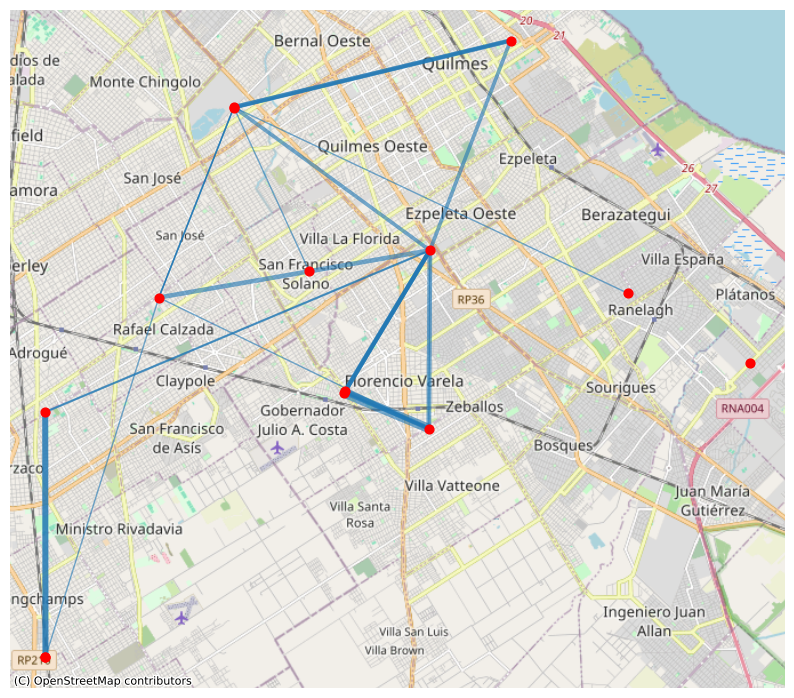

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

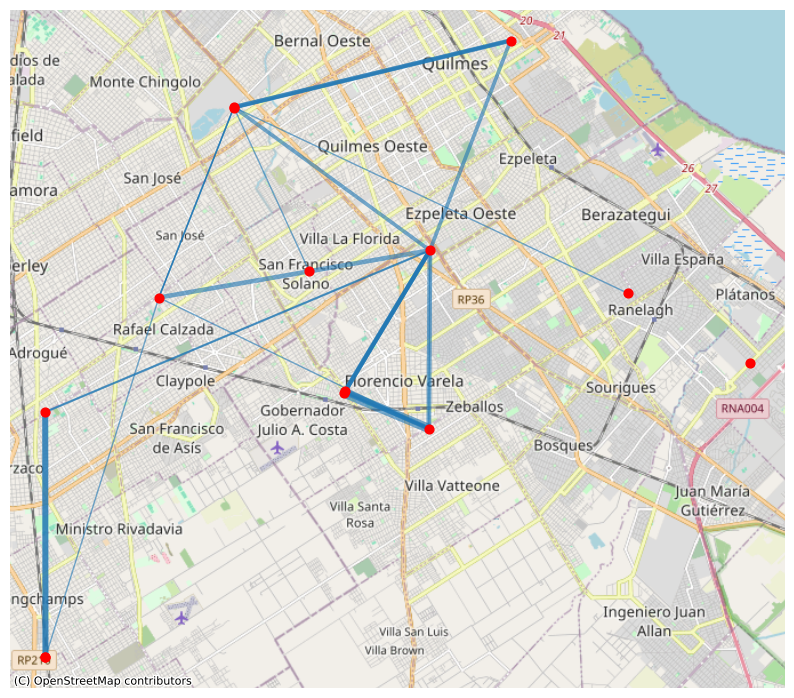

In [27]:
# generar red para todo el período
G, edges = bases.generar_red(df_traslados, fecha_inicio="2020-06-01", fecha_fin="2020-10-31")

# ahora G es el grafo de networkx
fig, ax = bases.plot_red_con_mapa(G, hosp_coord)
plt.show()

# podés usar funciones de plot de BASES
bases.plot_red_con_mapa(G, hosp_coord)